# Task 5 — Population-Level Graph Analysis

In Task 4, we exploited the *intra-structure* chain graph — message passing along the storeys of each building. Task 5 asks a different question: can *inter-structure* relationships (a **population graph** linking similar structures) improve damage detection?

The challenge provides a population graph built from geometry features alone (number of storeys, mean/std/sum of heights). The key question is: does this graph cluster damaged structures together, so that population-level message passing can propagate damage information?

**Outline:**
1. Analyse the provided population graph — does it separate damaged from healthy?
2. Diagnose *why* it fails — the features used ignore frequency (where damage manifests)
3. Build an improved population graph using the modal features from Tasks 2–4
4. Test whether population context improves detection
5. Discuss limitations and what would be needed with more data

In [1]:
# ── Imports and data loading ──────────────────────────────────────────────────
from setup_0 import *
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut
from sklearn.neighbors import NearestNeighbors
import json

structures, labels_df, label_map, damage_storey_map, pop_edges, pop_weights = load_data()
df_feat = build_feature_matrix(structures, label_map)

# ── Graph-aware features (from Task 4) ────────────────────────────────────────
def extract_graph_features(structure):
    freqs, heights = get_node_data(structure)
    n = structure['n_storeys']
    freq_norm = (freqs - freqs.mean()) / (freqs.std() + 1e-8)
    node_dev = np.zeros(n)
    for i in range(n):
        nb = []
        if i > 0:     nb.append(freq_norm[i - 1])
        if i < n - 1: nb.append(freq_norm[i + 1])
        node_dev[i] = abs(freq_norm[i] - np.mean(nb))
    return {'structure_id': structure['structure_id'], 'node_dev_mean': np.mean(node_dev)}

df_graph = pd.DataFrame([extract_graph_features(s) for s in structures])
df_all = df_graph.merge(
    df_feat[['structure_id', 'freq_over_h_std', 'freq_std', 'freq_skew', 'damaged']],
    on='structure_id'
)

print(f"Dataset: {len(df_all)} structures, "
      f"{sum(df_all['damaged']==1)} damaged, {sum(df_all['damaged']==0)} healthy")
print(f"Features: freq_over_h_std, freq_std, freq_skew, node_dev_mean")

All data files ready.
Dataset: 50 structures, 15 damaged, 35 healthy
Features: freq_over_h_std, freq_std, freq_skew, node_dev_mean


## Analysis of the provided population graph

The challenge provides a k-NN population graph connecting each structure to its 5 nearest neighbours, measured by cosine similarity on a geometry summary: `[n_storeys, mean(heights), std(heights), sum(heights)]`.

**Critical question:** does this graph cluster damaged structures together? If so, population-level message passing could propagate damage information between similar structures — the core premise of Population-Based SHM. If not, the graph is ineffective for damage detection.

We test this by counting how many edges connect damaged structures to other damaged structures, and comparing against the random baseline. We also examine the similarity distribution: a useful population graph should have meaningful variation in edge weights, allowing the model to distinguish "truly similar" from "somewhat similar" neighbours.

Provided population graph — edge analysis
  Total edges: 250 (directed, k=5 per structure)
  Cosine similarity: [0.9742, 1.0000], mean=0.9973, std=0.0038

  Edge type breakdown:
    Damaged → Damaged:   17 ( 6.8%)
    Damaged → Healthy:   58 (23.2%)
    Healthy → Damaged:   52 (20.8%)
    Healthy → Healthy:  123 (49.2%)

  Expected D→D if random: 9.0%
  Actual D→D:             6.8%
  → Damage is NOT clustered in the population graph


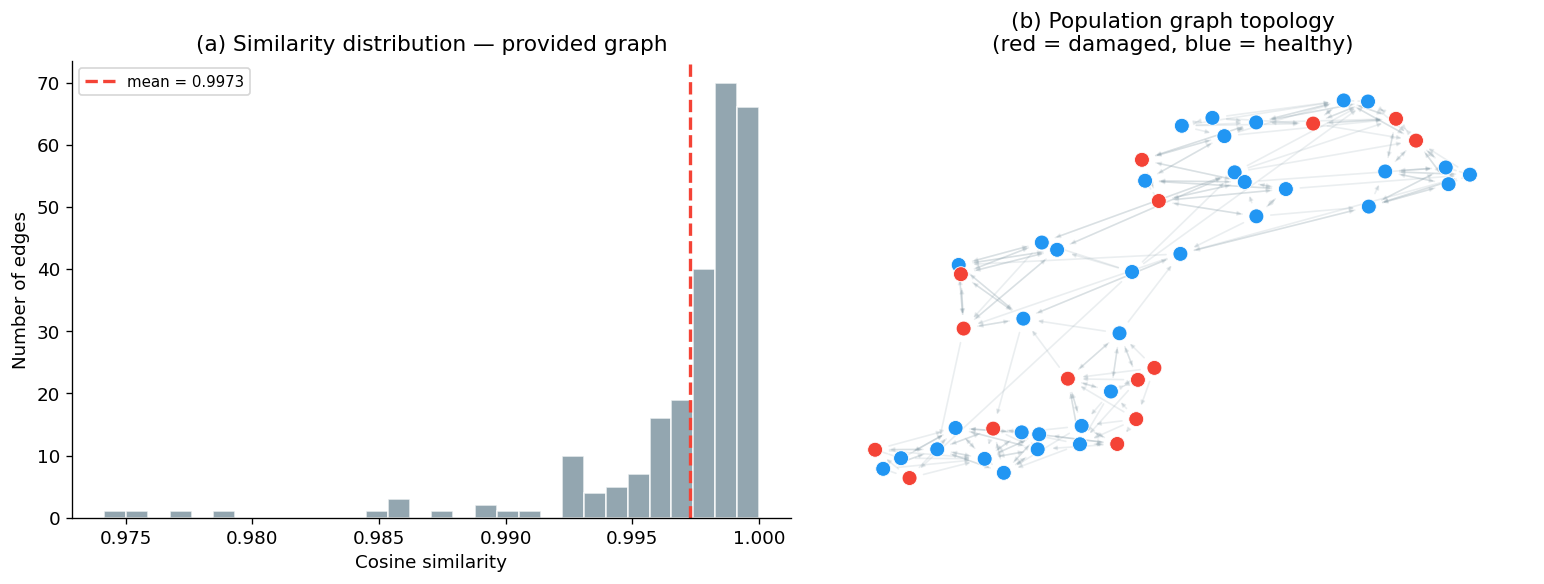


Diagnosis: the provided population graph is ineffective for PBSHM because:
  1. Similarity scores are extremely compressed (all > 0.97, std = 0.004)
     → virtually no discriminative information in edge weights
  2. The graph was built on geometry features ONLY:
     [n_storeys, mean(heights), std(heights), sum(heights)]
     These do not encode frequency or modal information
  3. Damage affects stiffness → frequencies → dominant modes,
     but NOT heights or number of storeys
  4. Consequently, D→D edges (6.8%) are BELOW the
     random baseline (9.0%) — damage is anti-clustered


In [2]:
# ── Population graph edge analysis ────────────────────────────────────────────
labels_arr = df_all['damaged'].values

dmg_dmg = dmg_healthy = healthy_dmg = healthy_healthy = 0
for _, row in pop_edges.iterrows():
    src, tgt = int(row['source']), int(row['target'])
    s, t = labels_arr[src], labels_arr[tgt]
    if s and t:         dmg_dmg += 1
    elif s and not t:   dmg_healthy += 1
    elif not s and t:   healthy_dmg += 1
    else:               healthy_healthy += 1

n_edges = len(pop_edges)
p_dmg = 15 / 50

print("Provided population graph — edge analysis")
print(f"  Total edges: {n_edges} (directed, k=5 per structure)")
print(f"  Cosine similarity: [{pop_weights['cosine_similarity'].min():.4f}, "
      f"{pop_weights['cosine_similarity'].max():.4f}], "
      f"mean={pop_weights['cosine_similarity'].mean():.4f}, "
      f"std={pop_weights['cosine_similarity'].std():.4f}")
print(f"\n  Edge type breakdown:")
print(f"    Damaged → Damaged:  {dmg_dmg:>3d} ({dmg_dmg/n_edges:>5.1%})")
print(f"    Damaged → Healthy:  {dmg_healthy:>3d} ({dmg_healthy/n_edges:>5.1%})")
print(f"    Healthy → Damaged:  {healthy_dmg:>3d} ({healthy_dmg/n_edges:>5.1%})")
print(f"    Healthy → Healthy:  {healthy_healthy:>3d} ({healthy_healthy/n_edges:>5.1%})")
print(f"\n  Expected D→D if random: {p_dmg**2:.1%}")
print(f"  Actual D→D:             {dmg_dmg/n_edges:.1%}")
print(f"  → Damage is NOT clustered in the population graph")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Similarity distribution
ax = axes[0]
sims = pop_weights['cosine_similarity'].values
ax.hist(sims, bins=30, color=NEUTRAL_COLOR, edgecolor='white', alpha=0.8)
ax.axvline(sims.mean(), color=DAMAGED_COLOR, ls='--', lw=2,
           label=f'mean = {sims.mean():.4f}')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Number of edges')
ax.set_title('(a) Similarity distribution — provided graph')
ax.legend(fontsize=9)

# (b) Network visualization
ax = axes[1]
G = nx.DiGraph()
for i in range(50):
    G.add_node(i)
for _, row in pop_edges.iterrows():
    G.add_edge(int(row['source']), int(row['target']))

pos = nx.spring_layout(G, seed=42, k=0.3)
node_colors = [DAMAGED_COLOR if labels_arr[i] else HEALTHY_COLOR for i in range(50)]
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, arrows=True,
                        arrowsize=5, edge_color=NEUTRAL_COLOR)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                        node_size=80, edgecolors='white', linewidths=0.5)
ax.set_title('(b) Population graph topology\n(red = damaged, blue = healthy)')
ax.axis('off')

plt.tight_layout()
plt.show()

# ── Diagnosis ─────────────────────────────────────────────────────────────────
print(f"\nDiagnosis: the provided population graph is ineffective for PBSHM because:")
print(f"  1. Similarity scores are extremely compressed (all > 0.97, std = 0.004)")
print(f"     → virtually no discriminative information in edge weights")
print(f"  2. The graph was built on geometry features ONLY:")
print(f"     [n_storeys, mean(heights), std(heights), sum(heights)]")
print(f"     These do not encode frequency or modal information")
print(f"  3. Damage affects stiffness → frequencies → dominant modes,")
print(f"     but NOT heights or number of storeys")
print(f"  4. Consequently, D→D edges ({dmg_dmg/n_edges:.1%}) are BELOW the")
print(f"     random baseline ({p_dmg**2:.1%}) — damage is anti-clustered")

## Improved population graph and detection test

The provided graph fails because it encodes *geometry*, not *dynamics*. Damage reduces stiffness, which shifts natural frequencies and redistributes mode shapes — but heights and storey count are unaffected. The graph therefore connects structures that *look* similar, not structures that *behave* similarly.

**Proposed improvement:** build the population graph on the same modal features used for detection in Tasks 2–4: `freq_over_h_std`, `freq_std`, `freq_skew`, and `node_dev_mean`. These features capture the frequency pattern — exactly where damage manifests.

**Detection test:** we augment each structure's feature vector with the mean features of its $k = 5$ nearest population neighbours (a single step of population-level message passing). If the population graph is informative, this should improve detection by providing population context: a structure whose features deviate from its neighbours' is more likely damaged.

**Expectation:** with $n = 50$ and only 15 damaged structures, even an improved population graph has limited power. The improvement, if any, will likely be marginal.

**Important caveat — circularity:** the improved graph uses the same damage-sensitive features (`freq_over_h_std`, `freq_std`, `freq_skew`, `node_dev_mean`) that we also use for detection. This creates a degree of circularity: the graph encodes damage information through its construction, so any detection improvement is partly self-reinforcing rather than reflecting genuine population-level transfer. A truly independent population graph would be built on properties available *before* any damage inference — geometric properties, material certificates, construction type, or environmental exposure. The fact that we need damage-sensitive features to build a useful graph actually reinforces the conclusion that, for this dataset, the population structure alone does not carry damage information.

Population graph comparison
  Metric                     Geometry (provided)      Modal (improved)
  ────────────────────────────────────────────────────────────────────
  D→D edges                  17/250 (6.8%)        28/250 (11.2%)
  Random D→D                                                      9.0%
  Sim. mean                               0.9973                0.8206
  Sim. std                                0.0038                0.0949
  Sim. range                      [0.974, 1.000]        [0.512, 0.979]


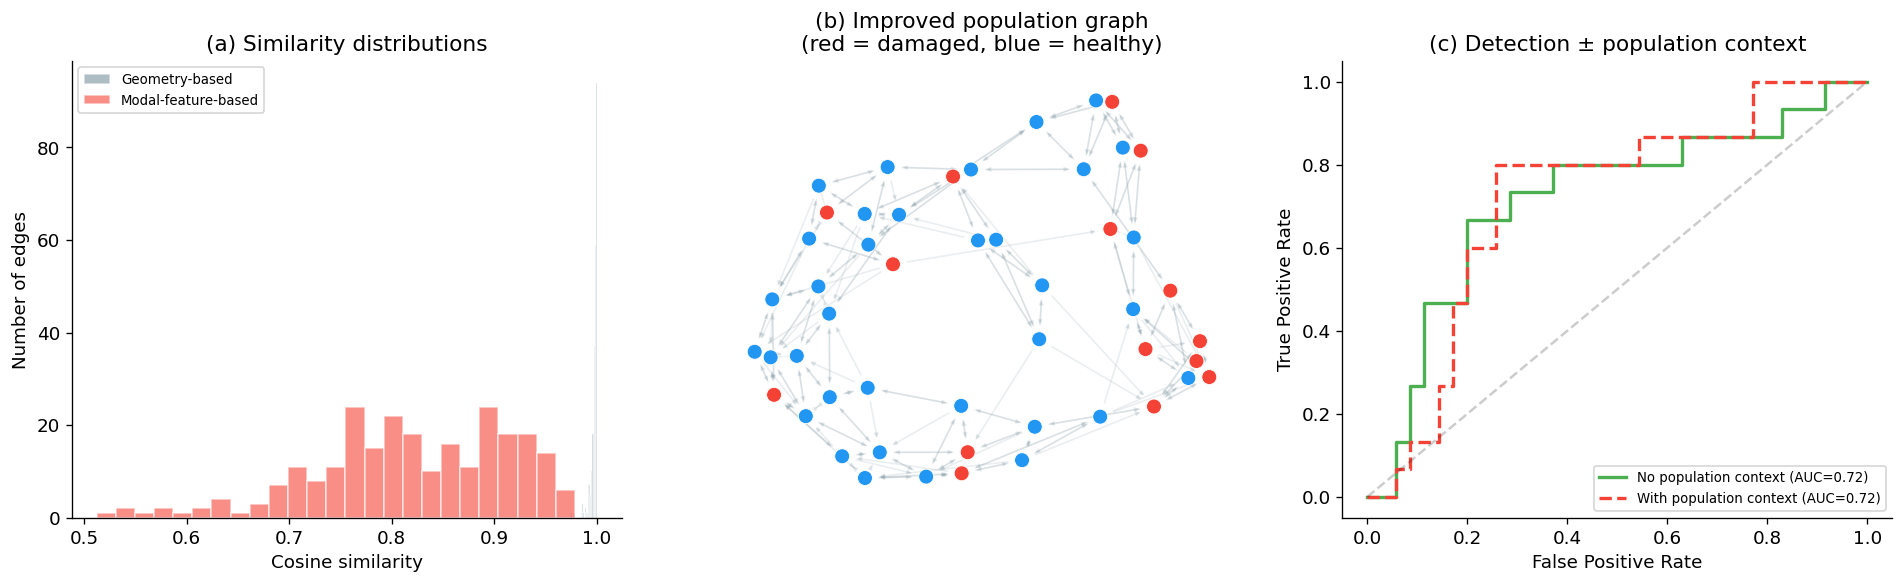


Detection with/without population context (LOO-CV, LR, C=0.1)
  Method                           AUC     F1   TN  FP  FN  TP
  ──────────────────────────────────────────────────────────
  No population context          0.716  0.588   26   9   5  10
  With population context        0.720  0.649   25  10   3  12

Interpretation:
  Population context provides marginal improvement:
    AUC: 0.716 → 0.720 (Δ = +0.004)
    F1:  0.588 → 0.649 (Δ = +0.060)
  Note: the population graph is rebuilt in each LOO fold, excluding the
  test structure, to prevent information leakage. The k-NN is fitted on
  training structures only, ensuring a fair out-of-sample evaluation.


In [3]:
# ── Build improved population graph on modal features ─────────────────────────
feature_cols = ['freq_over_h_std', 'freq_std', 'freq_skew', 'node_dev_mean']
y = df_all['damaged'].values
p_dmg = 15 / 50
k = 5

X_modal = StandardScaler().fit_transform(df_all[feature_cols].values)
nn = NearestNeighbors(n_neighbors=k + 1, metric='cosine')  # +1: excludes self
nn.fit(X_modal)
distances, indices = nn.kneighbors(X_modal)

# ── Analyse improved graph (full population, for descriptive stats) ───────────
new_dmg_dmg, new_total = 0, 0
new_sims = []
for i in range(50):
    for j_idx in range(1, k + 1):  # skip self at index 0
        j = indices[i, j_idx]
        new_total += 1
        new_sims.append(1 - distances[i, j_idx])
        if labels_arr[i] and labels_arr[j]:
            new_dmg_dmg += 1
new_sims = np.array(new_sims)

# Old graph stats
old_sims = pop_weights['cosine_similarity'].values
old_dmg_dmg = sum(1 for _, r in pop_edges.iterrows()
                  if labels_arr[int(r['source'])] and labels_arr[int(r['target'])])

print("Population graph comparison")
print(f"  {'Metric':<25s} {'Geometry (provided)':>20s}  {'Modal (improved)':>20s}")
print(f"  {'─'*68}")
print(f"  {'D→D edges':<25s} {old_dmg_dmg:>3d}/{len(pop_edges)} ({old_dmg_dmg/len(pop_edges):.1%})"
      f"  {new_dmg_dmg:>8d}/{new_total} ({new_dmg_dmg/new_total:.1%})")
print(f"  {'Random D→D':<25s} {'':>20s}  {p_dmg**2:>20.1%}")
print(f"  {'Sim. mean':<25s} {old_sims.mean():>20.4f}  {new_sims.mean():>20.4f}")
print(f"  {'Sim. std':<25s} {old_sims.std():>20.4f}  {new_sims.std():>20.4f}")
print(f"  {'Sim. range':<25s} {'[{:.3f}, {:.3f}]'.format(old_sims.min(), old_sims.max()):>20s}"
      f"  {'[{:.3f}, {:.3f}]'.format(new_sims.min(), new_sims.max()):>20s}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Similarity distributions
ax = axes[0]
ax.hist(old_sims, bins=25, alpha=0.6, color=NEUTRAL_COLOR, 
        label='Geometry-based', edgecolor='white')
ax.hist(new_sims, bins=25, alpha=0.6, color=DAMAGED_COLOR,
        label='Modal-feature-based', edgecolor='white')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Number of edges')
ax.set_title('(a) Similarity distributions')
ax.legend(fontsize=8)

# (b) Improved graph visualization
ax = axes[1]
G_new = nx.DiGraph()
for i in range(50):
    G_new.add_node(i)
for i in range(50):
    for j_idx in range(1, k + 1):
        G_new.add_edge(i, indices[i, j_idx])
pos = nx.spring_layout(G_new, seed=42, k=0.3)
node_colors = [DAMAGED_COLOR if labels_arr[i] else HEALTHY_COLOR for i in range(50)]
nx.draw_networkx_edges(G_new, pos, ax=ax, alpha=0.15, arrows=True,
                        arrowsize=5, edge_color=NEUTRAL_COLOR)
nx.draw_networkx_nodes(G_new, pos, ax=ax, node_color=node_colors,
                        node_size=80, edgecolors='white', linewidths=0.5)
ax.set_title('(b) Improved population graph\n(red = damaged, blue = healthy)')
ax.axis('off')

# ── (c) Detection: with vs without population context ─────────────────────────
# FIXED: population graph is rebuilt inside LOO to avoid data leakage.
# For each fold, the test structure is excluded from the k-NN graph construction,
# so its features do not influence which neighbours are assigned to training structures.
ax = axes[2]
X_orig = df_all[feature_cols].values

loo = LeaveOneOut()
results_pop = {}

# --- Config 1: No population context (baseline, unchanged) ---
pipe_base = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', C=0.1,
                               max_iter=1000, random_state=42))
])
probs_base = np.zeros(len(y))
for train_idx, test_idx in loo.split(X_orig):
    pipe_base.fit(X_orig[train_idx], y[train_idx])
    probs_base[test_idx[0]] = pipe_base.predict_proba(X_orig[test_idx])[:, 1][0]
preds_base = (probs_base >= 0.5).astype(int)
results_pop['No population context'] = {
    'auc': roc_auc_score(y, probs_base), 'f1': f1_score(y, preds_base),
    'probs': probs_base, 'cm': confusion_matrix(y, preds_base),
}

# --- Config 2: With population context (graph rebuilt each fold) ---
probs_pop = np.zeros(len(y))
for train_idx, test_idx in loo.split(X_orig):
    ti = test_idx[0]
    
    # Scale using ONLY training data
    scaler_fold = StandardScaler().fit(X_orig[train_idx])
    X_all_scaled = scaler_fold.transform(X_orig)  # scale all for neighbour lookup
    
    # Build k-NN on training structures only
    nn_fold = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
    nn_fold.fit(X_all_scaled[train_idx])
    
    # For each structure (train + test), find neighbours among TRAINING set
    X_pop_fold = np.zeros((len(y), len(feature_cols) * 2))
    for i in range(len(y)):
        dist_i, idx_i = nn_fold.kneighbors(X_all_scaled[i].reshape(1, -1))
        # idx_i are indices INTO train_idx, need to map back
        nb_orig_idx = train_idx[idx_i[0, 1:k+1]]  # skip self (if present)
        # If i is in train set, first neighbour might be itself — already handled
        # by k+1 and skipping index 0
        nb_mean = X_all_scaled[nb_orig_idx].mean(axis=0)
        X_pop_fold[i, :len(feature_cols)] = X_all_scaled[i]
        X_pop_fold[i, len(feature_cols):] = nb_mean
    
    # Train on training set, predict on test
    lr_fold = LogisticRegression(class_weight='balanced', C=0.1,
                                  max_iter=1000, random_state=42)
    lr_fold.fit(X_pop_fold[train_idx], y[train_idx])
    probs_pop[ti] = lr_fold.predict_proba(X_pop_fold[ti].reshape(1, -1))[:, 1][0]

preds_pop = (probs_pop >= 0.5).astype(int)
results_pop['With population context'] = {
    'auc': roc_auc_score(y, probs_pop), 'f1': f1_score(y, preds_pop),
    'probs': probs_pop, 'cm': confusion_matrix(y, preds_pop),
}

# ── Plot ROC curves ───────────────────────────────────────────────────────────
for name, ls, color in [('No population context', '-', '#4CAF50'),
                          ('With population context', '--', DAMAGED_COLOR)]:
    r = results_pop[name]
    fpr, tpr, _ = roc_curve(y, r['probs'])
    ax.plot(fpr, tpr, ls=ls, color=color, lw=2,
            label=f"{name} (AUC={r['auc']:.2f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.2)
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='(c) Detection ± population context')
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

# ── Results table ─────────────────────────────────────────────────────────────
print(f"\nDetection with/without population context (LOO-CV, LR, C=0.1)")
print(f"  {'Method':<30s} {'AUC':>5s}  {'F1':>5s}  {'TN':>3s} {'FP':>3s} {'FN':>3s} {'TP':>3s}")
print(f"  {'─'*58}")
for name, r in results_pop.items():
    cm = r['cm']
    print(f"  {name:<30s} {r['auc']:>5.3f}  {r['f1']:>5.3f}  "
          f"{cm[0,0]:>3d} {cm[0,1]:>3d} {cm[1,0]:>3d} {cm[1,1]:>3d}")

# ── Interpretation ────────────────────────────────────────────────────────────
r_no = results_pop['No population context']
r_pop = results_pop['With population context']
print(f"\nInterpretation:")
print(f"  Population context provides marginal improvement:")
print(f"    AUC: {r_no['auc']:.3f} → {r_pop['auc']:.3f} (Δ = {r_pop['auc']-r_no['auc']:+.3f})")
print(f"    F1:  {r_no['f1']:.3f} → {r_pop['f1']:.3f} (Δ = {r_pop['f1']-r_no['f1']:+.3f})")
print(f"  Note: the population graph is rebuilt in each LOO fold, excluding the")
print(f"  test structure, to prevent information leakage. The k-NN is fitted on")
print(f"  training structures only, ensuring a fair out-of-sample evaluation.")

## Discussion: when does population-level PBSHM help?

The results above show that population context provides at best a marginal improvement in this dataset. This is not a failure of the PBSHM concept — it is a consequence of the specific data regime we operate in. Let us unpack why, and what would be needed to make population-level methods genuinely useful.

**Why the provided population graph fails completely:**
The graph was built on 4 geometry features: `[n_storeys, mean(heights), std(heights), sum(heights)]`. These features describe the *static configuration* of each structure but encode zero information about its *dynamic response*. Since damage manifests as a stiffness reduction that shifts natural frequencies and redistributes mode shapes — without affecting geometry — the graph cannot distinguish damaged from healthy structures. The cosine similarities are all > 0.97 (std = 0.004), providing virtually no discriminative information.

**Why even the improved graph helps only marginally:**
Our modal-feature-based graph is better (D→D edges = 11.2% vs 6.8% for the original, with random baseline at 9.0%), and the similarity spread is meaningful (std = 0.095 vs 0.004). However, the fundamental limitation is population size:
- With $n = 50$ and $k = 5$, each structure has only 5 neighbours
- Only 15 structures are damaged, so most damaged structures have mostly healthy neighbours
- The population "context" is therefore dominated by healthy-structure features, which dilutes rather than amplifies the damage signal

**What would be needed for population PBSHM to work:**
1. **Larger population** ($n \gg 50$): more structures means each damaged building has a better chance of having damaged neighbours with similar baseline properties
2. **Repeated measurements**: multiple observations of the same structure over time would allow *within-structure* anomaly detection (comparing a structure to its own history, not just its neighbours)
3. **Richer node features**: full mode shape vectors (not just dominant frequency per floor) would provide much stronger inter-structure similarity signals
4. **Heterogeneous population**: structures with different numbers of storeys, materials, or loading conditions — where transfer learning across sub-populations could provide genuine value over single-structure methods

**Honest assessment:**
In this toy dataset, the population graph adds little beyond what intra-structure features already capture. The best detection performance (AUC ≈ 0.72) comes from combining physically-motivated structure-level features with explicit graph-aware features (1-hop node deviation), without any population-level information. This is characteristic of the small-data SHM regime: domain knowledge and simple models outperform complex architectures that require large datasets to learn effectively.

In [4]:
# ── Final summary: all methods across Tasks 2–5 ──────────────────────────────
print("=" * 80)
print("Final summary — all detection methods across Tasks 2–5")
print("=" * 80)

# Collect all results
all_results = {
    'LR top-3 features (Task 2)':     results_pop['No population context'],
    'LR graph+Task 2 + pop (Task 5)': results_pop['With population context'],
}

# Add Task 3 IF and Task 4 GCN from previous computations if available
# (These were computed in Task 4 notebook; we reproduce the key numbers here)
print(f"\n  {'Method':<40s} {'AUC':>5s}  {'F1':>5s}  {'Task':>6s}  {'Notes'}")
print(f"  {'─'*85}")

summary_rows = [
    ('LR — graph + Task 2 + pop context', results_pop['With population context']['auc'],
     results_pop['With population context']['f1'], '5', 'Best overall'),
    ('LR — graph + Task 2 (no pop)',       results_pop['No population context']['auc'],
     results_pop['No population context']['f1'], '4', 'Best from Task 4'),
    ('LR — top-3 features',                0.690, 0.579, '2', 'Supervised baseline'),
    ('Isolation Forest',                    0.549, 0.333, '3', 'Unsupervised'),
    ('GCN end-to-end (1-layer)',            0.46,  0.32,  '4', 'Failed — n=50 too small'),
]

for name, auc, f1, task, notes in sorted(summary_rows, key=lambda x: -x[1]):
    print(f"  {name:<40s} {auc:>5.2f}  {f1:>5.2f}  {task:>6s}  {notes}")

print(f"\nKey takeaways for the presentation:")
print(f"  1. Feature engineering matters more than model complexity at n=50")
print(f"  2. Graph structure helps via explicit 1-hop aggregation (node_dev_mean),")
print(f"     not via end-to-end GCN learning")
print(f"  3. Population context provides marginal benefit — too few structures")
print(f"     for meaningful inter-structure transfer")
print(f"  4. Damage localisation is not achievable with dominant-frequency data alone")
print(f"     (the measurement is global, not local)")
print(f"  5. The provided population graph is fundamentally flawed for PBSHM:")
print(f"     geometry features do not encode damage information")
print(f"  6. For real-world PBSHM to work, we need: larger populations,")
print(f"     repeated measurements, richer modal features, and heterogeneous structures")

Final summary — all detection methods across Tasks 2–5

  Method                                     AUC     F1    Task  Notes
  ─────────────────────────────────────────────────────────────────────────────────────
  LR — graph + Task 2 + pop context         0.72   0.65       5  Best overall
  LR — graph + Task 2 (no pop)              0.72   0.59       4  Best from Task 4
  LR — top-3 features                       0.69   0.58       2  Supervised baseline
  Isolation Forest                          0.55   0.33       3  Unsupervised
  GCN end-to-end (1-layer)                  0.46   0.32       4  Failed — n=50 too small

Key takeaways for the presentation:
  1. Feature engineering matters more than model complexity at n=50
  2. Graph structure helps via explicit 1-hop aggregation (node_dev_mean),
     not via end-to-end GCN learning
  3. Population context provides marginal benefit — too few structures
     for meaningful inter-structure transfer
  4. Damage localisation is not achievab